<h1>DNN Model</h1>

Using data in advanced preprocssing

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import os
from PIL import Image
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import tensorflow as tf
from tensorflow.keras import layers, models



In [3]:
import pandas as pd
import os

def clean_metadata(meta_path, img_dir):
    df = pd.read_csv(meta_path)
    valid_rows = []
    for idx, row in df.iterrows():
        base_name = row['photo_id']
        found = False
        for ext in ['.jpg', '.png', '.jpeg']:
            img_path = os.path.join(img_dir, base_name + ext).replace("\\", "/")
            if os.path.exists(img_path):
                found = True
                break
        if found:
            valid_rows.append(row)
        else:
            print(f"Will remove missing: {img_dir}/{base_name}")
    clean_df = pd.DataFrame(valid_rows)
    clean_csv_path = meta_path.replace('.csv', '_clean.csv')
    clean_df.to_csv(clean_csv_path, index=False)
    print(f"Saved cleaned CSV to {clean_csv_path} (now only valid images)")
    return clean_df

# Clean val and test sets
clean_metadata("C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\val_metadata.csv", "C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\split_photos\\val")
clean_metadata("C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\test_metadata.csv", "C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\split_photos\\test")



Will remove missing: C:\Users\Admin\Downloads\CV_PROJECT_1\split_photos\val/NfayhoTudVJQsEF-XlPyjw
Will remove missing: C:\Users\Admin\Downloads\CV_PROJECT_1\split_photos\val/9BvYOtforBBP6MvvDogtmw
Will remove missing: C:\Users\Admin\Downloads\CV_PROJECT_1\split_photos\val/AMSyCOP3-Eb_ivNA8w1Vhw
Will remove missing: C:\Users\Admin\Downloads\CV_PROJECT_1\split_photos\val/QhATx1B1n8uf8C6siMNTfA
Saved cleaned CSV to C:\Users\Admin\Downloads\CV_PROJECT_1\val_metadata_clean.csv (now only valid images)
Will remove missing: C:\Users\Admin\Downloads\CV_PROJECT_1\split_photos\test/2S78q98b_VpBD7vkrDE5-A
Saved cleaned CSV to C:\Users\Admin\Downloads\CV_PROJECT_1\test_metadata_clean.csv (now only valid images)


,photo_id,business_id,caption,label
0,bdTdwyFDbb9NdjBOQGamaQ,52iW9Eo-EWJZXYYjQ5pAKw,NaN,inside
1,adXfpHpKxd3rHRFXgytG0A,_LgI5387qAmMuS8i6h69cg,NO. 52 - Bourbon * House Made Blueberry Shrub ...,drink
2,cvfjsiUk1UzGGomb4mCtpQ,K5gNiYeNriJsaqyJewZl0w,"Nachos can be loaded w/ grilled adobo chicken,...",food
3,u4Xr1h2YIAONEGqWS_K7RA,9OCsSHr6OCSyR91BFIbszQ,NaN,outside
4,f8kmnyacWttiSBEL4ryygA,l4IeGBHXV2E8S8COd9rx9A,Doing our #ShopLocal #SmallBizSaturday spendin...,menu
...,...,...,...,...
2145,Mau7MW5eyZmDDGUutwi3Bg,RsZFGqDyTUk9kEJzVLWHdQ,NaN,menu
2146,ofY1OKtI7LydY8S9KhVyqA,8RZwphljLVABXgnDgMj6Hg,Chicken with Dijon sauce over rice. Really goo...,food
2147,aieo3TMOcbVn0LtihVwFIA,QJOC6Uz-RCpzPB6aMjtP9Q,"""Happy Camper"" smoothie! $5. Huge. And soooo g...",drink
2148,wg7RB6RiW4ejF-RnjV_4uA,J-ciDDEdIHMcChGIyKZnOg,Fun whisk lighting fixtures!!,inside


There are 5 Missing photos hence removed those photos for safer side

In [5]:
def load_images_and_labels(meta_path, img_dir, img_size=(128,128)):
    df = pd.read_csv(meta_path)
    X, y = [], []
    for idx, row in df.iterrows():
        base_name = row['photo_id']
        for ext in ['.jpg', '.png', '.jpeg']:
            img_path = os.path.join(img_dir, base_name + ext).replace("\\", "/")
            if os.path.exists(img_path):
                #need to convert every images in test, train and val to same channel rgb
                img = Image.open(img_path).convert("RGB").resize(img_size)
                X.append(np.array(img))
                y.append(row['label'])
                break
    return np.array(X)/255.0, np.array(y)


In [3]:
# Paths to your clean files and directories
train_meta = "C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\train_augmented_metadata.csv"          # (Assume train data is fine)
train_img_dir = "C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\augmented_photos\\train"
val_meta = "C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\val_metadata_clean.csv"
val_img_dir = "C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\split_photos\\val"
test_meta = "C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\test_metadata_clean.csv"
test_img_dir = "C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\split_photos\\test"


In [6]:
# Load all sets
X_train, y_train = load_images_and_labels(train_meta, train_img_dir)

In [7]:
X_val, y_val = load_images_and_labels(val_meta, val_img_dir)

In [8]:
X_test, y_test = load_images_and_labels(test_meta, test_img_dir)

In [9]:
lb = LabelBinarizer()
lb.fit(y_train)  # Only fit on training data

LabelBinarizer()

In [10]:
y_train_bin = lb.transform(y_train)
y_val_bin = lb.transform(y_val)     # Safe if val labels are in training
y_test_bin = lb.transform(y_test)   # May raise error if test has unseen class


In [11]:
print("Train:", X_train.shape, y_train_bin.shape)
print("Val:", X_val.shape, y_val_bin.shape)
print("Test:", X_test.shape, y_test_bin.shape)
print("Classes:", lb.classes_)

Train: (17192, 128, 128, 3) (17192, 5)
Val: (2146, 128, 128, 3) (2146, 5)
Test: (2149, 128, 128, 3) (2149, 5)
Classes: ['drink' 'food' 'inside' 'menu' 'outside']


**Model Building**

Organize Data by Folder Structure
When trying to load all images into RAM at once, which is not feasible for large datasets or machines with limited memory.

In [12]:
import os
import pandas as pd
import shutil

def organize_images_by_class(meta_path, img_dir, out_dir, exts=['.jpg', '.png', '.jpeg']):
    df = pd.read_csv(meta_path)
    os.makedirs(out_dir, exist_ok=True)
    missing = 0
    for idx, row in df.iterrows():
        photo_id = row['photo_id']
        label = str(row['label'])
        # Create class folder if it doesn't exist
        class_dir = os.path.join(out_dir, label)
        os.makedirs(class_dir, exist_ok=True)
        # Try all possible extensions
        found = False
        for ext in exts:
            src = os.path.join(img_dir, photo_id + ext)
            if os.path.exists(src):
                dst = os.path.join(class_dir, photo_id + ext)
                shutil.copy2(src, dst)
                found = True
                break
        if not found:
            print(f"Missing: {photo_id}")
            missing += 1
    print(f"Done. Copied {len(df)-missing} files. {missing} were missing.")

# Usage for training set:
organize_images_by_class(
    meta_path="C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\train_augmented_metadata.csv",
    img_dir="C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\augmented_photos\\train",
    out_dir="C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\keras_data\\train"
)

# Usage for validation set:
organize_images_by_class(
    meta_path="C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\val_metadata_clean.csv",
    img_dir="C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\split_photos\\val",
    out_dir="C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\keras_data\\val"
)

# Usage for test set:
organize_images_by_class(
    meta_path="C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\test_metadata_clean.csv",
    img_dir="C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\split_photos\\test",
    out_dir="C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\keras_data\\test"
)

Done. Copied 17192 files. 0 were missing.
Done. Copied 2146 files. 0 were missing.
Done. Copied 2149 files. 0 were missing.


In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (128, 128)
batch_size = 64

train_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\keras_data\\train', target_size=img_size, batch_size=batch_size, class_mode='categorical'
)
val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\keras_data\\val', target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)
test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\keras_data\\test', target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)


Found 17192 images belonging to 5 classes.
Found 2146 images belonging to 5 classes.
Found 2149 images belonging to 5 classes.


**Basic Model 1**

In [14]:
from tensorflow.keras import Input, layers, models

model = models.Sequential([
    Input(shape=(128, 128, 3)),        # Input layer for 128x128 RGB images
    layers.Flatten(),                 # Converts image to 1D vector (128*128*3 = 49,152)
    
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.4),
    
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    
    layers.Dense(train_gen.num_classes, activation='softmax')  # Output layer
])



In [15]:
model.compile(optimizer='adam', 
              loss='categorical_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.AUC()])

In [16]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=12
)

Epoch 1/12
269/269 ━━━━━━━━━━━━━━━━━━━━ 181s 661ms/step - accuracy: 0.2510 - auc: 0.5614 - loss: 4.8556 - recall: 0.0930 - val_accuracy: 0.2344 - val_auc: 0.5864 - val_loss: 1.5453 - val_recall: 0.0000e+00
Epoch 2/12
269/269 ━━━━━━━━━━━━━━━━━━━━ 80s 295ms/step - accuracy: 0.2524 - auc: 0.6043 - loss: 1.5338 - recall: 0.0144 - val_accuracy: 0.2302 - val_auc: 0.5823 - val_loss: 1.5464 - val_recall: 0.0000e+00
Epoch 3/12
269/269 ━━━━━━━━━━━━━━━━━━━━ 79s 295ms/step - accuracy: 0.2367 - auc: 0.5860 - loss: 1.5392 - recall: 0.0039 - val_accuracy: 0.2390 - val_auc: 0.5928 - val_loss: 1.5400 - val_recall: 0.0023
Epoch 4/12
269/269 ━━━━━━━━━━━━━━━━━━━━ 80s 297ms/step - accuracy: 0.2686 - auc: 0.6209 - loss: 1.5178 - recall: 0.0279 - val_accuracy: 0.3476 - val_auc: 0.6909 - val_loss: 1.4458 - val_recall: 0.0722
Epoch 5/12
269/269 ━━━━━━━━━━━━━━━━━━━━ 82s 306ms/step - accuracy: 0.3034 - auc: 0.6502 - loss: 1.4871 - recall: 0.0544 - val_accuracy: 0.3346 - val_auc: 0.6926 - val_loss: 1.4315 - val_r

In [17]:
# Evaluate on test set
test_preds = model.predict(X_test)
test_pred_labels = np.argmax(test_preds, axis=1)
test_true_labels = np.argmax(y_test_bin, axis=1)


68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


In [18]:
print("\nClassification report:\n", classification_report(test_true_labels, test_pred_labels, target_names=lb.classes_))
print("Confusion Matrix:\n", confusion_matrix(test_true_labels, test_pred_labels))
print("AUC Score:", roc_auc_score(y_test_bin, test_preds, multi_class='ovr'))



Classification report:
               precision    recall  f1-score   support

       drink       0.00      0.00      0.00       507
        food       0.00      0.00      0.00       495
      inside       0.26      0.86      0.40       496
        menu       0.00      0.00      0.00       152
     outside       0.63      0.61      0.62       499

    accuracy                           0.34      2149
   macro avg       0.18      0.29      0.20      2149
weighted avg       0.21      0.34      0.24      2149

Confusion Matrix:
 [[  0   0 454   0  53]
 [  0   0 458   0  37]
 [  0   0 429   0  67]
 [  0   0 132   0  20]
 [  0   0 195   0 304]]
AUC Score: 0.6121644448141195


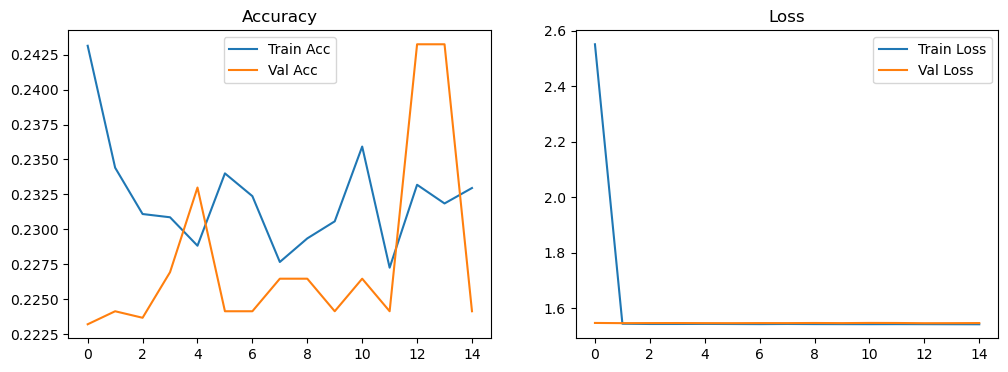

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (128, 128)
batch_size = 64

train_gen_eval = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\keras_data\\train',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # IMPORTANT for evaluation
)



Found 17192 images belonging to 5 classes.


In [24]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize

# Predict on training set
train_gen_eval.reset()
train_preds = model.predict(train_gen_eval, verbose=1)
train_pred_labels = np.argmax(train_preds, axis=1)
train_true_labels = train_gen_eval.classes

# Get class labels in correct order
class_labels = list(train_gen_eval.class_indices.keys())

# Print metrics
print("=== Train Data Evaluation ===")
print(classification_report(train_true_labels, train_pred_labels, target_names=class_labels))
print("Confusion Matrix (Train):\n", confusion_matrix(train_true_labels, train_pred_labels))
train_true_bin = label_binarize(train_true_labels, classes=range(len(class_labels)))
print("AUC (Train):", roc_auc_score(train_true_bin, train_preds, multi_class='ovr'))


269/269 ━━━━━━━━━━━━━━━━━━━━ 26s 97ms/step 
=== Train Data Evaluation ===
              precision    recall  f1-score   support

       drink       0.00      0.00      0.00      3971
        food       0.00      0.00      0.00      4006
      inside       0.23      1.00      0.38      4023
        menu       0.00      0.00      0.00      1191
     outside       0.00      0.00      0.00      4001

    accuracy                           0.23     17192
   macro avg       0.05      0.20      0.08     17192
weighted avg       0.05      0.23      0.09     17192

Confusion Matrix (Train):
 [[   0    0 3971    0    0]
 [   0    0 4006    0    0]
 [   0    0 4023    0    0]
 [   0    0 1191    0    0]
 [   0    0 4001    0    0]]
AUC (Train): 0.5002967007060828


This architecture is simple and has dropout regularization, but the results indicate it's not learning meaningful class distinctions. 
Model predicts everything as "inside"

Precision, recall, and F1-score are 0 for all other classes

AUC ≈ 0.5 → model not learning anything

Model Building 2 - Build a Better DNN (with Dropouts & Multiple Layers & Early stopping)

In [25]:
from tensorflow.keras import layers, models, Input
from tensorflow.keras.optimizers import Adam

model = models.Sequential([
    Input(shape=(128, 128, 3)),
    layers.Flatten(),

    # Deep Dense Layers
    layers.Dense(2048, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.1),

    # Output Layer
    layers.Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['accuracy'])


In [26]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    
)

Epoch 1/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 329s 1s/step - accuracy: 0.2317 - loss: 4.4684 - val_accuracy: 0.4007 - val_loss: 1.5432
Epoch 2/25
108/269 ━━━━━━━━━━━━━━━━━━━━ 3:17 1s/step - accuracy: 0.2933 - loss: 1.5322

ResourceExhaustedError: Graph execution error:

Detected at node PyFunc defined at (most recent call last):
<stack traces unavailable>
MemoryError: Unable to allocate 12.0 MiB for an array with shape (64, 128, 128, 3) and data type float32
Traceback (most recent call last):

  File "C:\Users\Admin\anaconda3\Lib\site-packages\tensorflow\python\ops\script_ops.py", line 270, in __call__
    ret = func(*args)
          ^^^^^^^^^^^

  File "C:\Users\Admin\anaconda3\Lib\site-packages\tensorflow\python\autograph\impl\api.py", line 643, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^

  File "C:\Users\Admin\anaconda3\Lib\site-packages\tensorflow\python\data\ops\from_generator_op.py", line 198, in generator_py_func
    values = next(generator_state.get_iterator(iterator_id))
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

  File "C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py", line 247, in _finite_gen

Reduce batch_size in ImageDataGenerator to fix the memory error

In [27]:
batch_size = 8  # Reduce from 64 → 8 to save memory

train_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'C:/Users/Admin/Downloads/CV_PROJECT_1/keras_data/train',
    target_size=(128, 128),
    batch_size=batch_size,
    class_mode='categorical'
)

val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'C:/Users/Admin/Downloads/CV_PROJECT_1/keras_data/val',
    target_size=(128, 128),
    batch_size=batch_size,
    class_mode='categorical'
)


Found 17192 images belonging to 5 classes.
Found 2146 images belonging to 5 classes.


In [28]:
import tensorflow as tf
tf.keras.backend.clear_session()
model = models.Sequential([
    Input(shape=(128, 128, 3)),
    layers.Flatten(),

    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.1),

    layers.Dense(train_gen.num_classes, activation='softmax')
])


In [29]:
model.compile(optimizer=Adam(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['accuracy'])


Added Early stopping to cut off early if validation loss stops improving


In [30]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=[early_stop]
)

Epoch 1/25
 616/2149 ━━━━━━━━━━━━━━━━━━━━ 13:49 541ms/step - accuracy: 0.2267 - loss: 6.3665 

ResourceExhaustedError: Graph execution error:

Detected at node PyFunc defined at (most recent call last):
<stack traces unavailable>
MemoryError: Unable to allocate 1.50 MiB for an array with shape (8, 128, 128, 3) and data type float32
Traceback (most recent call last):

  File "C:\Users\Admin\anaconda3\Lib\site-packages\tensorflow\python\ops\script_ops.py", line 270, in __call__
    ret = func(*args)
          ^^^^^^^^^^^

  File "C:\Users\Admin\anaconda3\Lib\site-packages\tensorflow\python\autograph\impl\api.py", line 643, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^

  File "C:\Users\Admin\anaconda3\Lib\site-packages\tensorflow\python\data\ops\from_generator_op.py", line 198, in generator_py_func
    values = next(generator_state.get_iterator(iterator_id))
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

  File "C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py", line 247, in _finite_gene

Though using batch size = 8 still getting resource exhausted error. Hence doing Sample a Subset of Images, Save to New Folders, Then Train Using ImageDataGenerator. Sample 20% of Images Per Class into a New Folder

In [3]:
import os
import shutil
import random

def sample_images(source_dir, target_dir, sample_fraction=0.2):
    os.makedirs(target_dir, exist_ok=True)

    for class_name in os.listdir(source_dir):
        class_path = os.path.join(source_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        
        all_images = os.listdir(class_path)
        sample_count = int(len(all_images) * sample_fraction)
        sampled_images = random.sample(all_images, sample_count)

        target_class_dir = os.path.join(target_dir, class_name)
        os.makedirs(target_class_dir, exist_ok=True)

        for img_name in sampled_images:
            src = os.path.join(class_path, img_name)
            dst = os.path.join(target_class_dir, img_name)
            shutil.copy(src, dst)

    print(f"Sampling complete. Sampled data saved in: {target_dir}")

# Sample 20% of training and validation sets
sample_images(
    source_dir='C:/Users/Admin/Downloads/CV_PROJECT_1/keras_data/train',
    target_dir='C:/Users/Admin/Downloads/CV_PROJECT_1/keras_data/train_sampled',
    sample_fraction=0.2
)

sample_images(
    source_dir='C:/Users/Admin/Downloads/CV_PROJECT_1/keras_data/val',
    target_dir='C:/Users/Admin/Downloads/CV_PROJECT_1/keras_data/val_sampled',
    sample_fraction=0.2
)


Sampling complete. Sampled data saved in: C:/Users/Admin/Downloads/CV_PROJECT_1/keras_data/train_sampled
Sampling complete. Sampled data saved in: C:/Users/Admin/Downloads/CV_PROJECT_1/keras_data/val_sampled


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

batch_size = 16
img_size = (128, 128)

train_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'C:/Users/Admin/Downloads/CV_PROJECT_1/keras_data/train_sampled',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'C:/Users/Admin/Downloads/CV_PROJECT_1/keras_data/val_sampled',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)


Found 11566 images belonging to 5 classes.
Found 1305 images belonging to 5 classes.


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.optimizers import Adam

tf.keras.backend.clear_session()

model = models.Sequential([
    Input(shape=(128, 128, 3)),
    layers.Flatten(),

    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.1),

    layers.Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['accuracy'])


In [6]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


In [7]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[early_stop]
)


Epoch 1/20
723/723 ━━━━━━━━━━━━━━━━━━━━ 397s 545ms/step - accuracy: 0.2401 - loss: 4.3510 - val_accuracy: 0.2751 - val_loss: 1.5559
Epoch 2/20
723/723 ━━━━━━━━━━━━━━━━━━━━ 376s 520ms/step - accuracy: 0.2383 - loss: 1.5507 - val_accuracy: 0.2368 - val_loss: 1.5508
Epoch 3/20
723/723 ━━━━━━━━━━━━━━━━━━━━ 382s 528ms/step - accuracy: 0.2349 - loss: 1.5444 - val_accuracy: 0.2307 - val_loss: 1.5490
Epoch 4/20
723/723 ━━━━━━━━━━━━━━━━━━━━ 375s 519ms/step - accuracy: 0.2354 - loss: 1.5447 - val_accuracy: 0.2307 - val_loss: 1.5511
Epoch 5/20
723/723 ━━━━━━━━━━━━━━━━━━━━ 375s 519ms/step - accuracy: 0.2432 - loss: 1.5456 - val_accuracy: 0.2031 - val_loss: 1.5500
Epoch 6/20
723/723 ━━━━━━━━━━━━━━━━━━━━ 371s 513ms/step - accuracy: 0.2247 - loss: 1.5486 - val_accuracy: 0.2307 - val_loss: 1.5501


In [12]:
# Evaluate on test set
test_preds = model.predict(X_test)
test_pred_labels = np.argmax(test_preds, axis=1)
test_true_labels = np.argmax(y_test_bin, axis=1)


68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step


NameError: name 'y_test_bin' is not defined

Tuning Step 1: Batch Normalization and Class Imbalance Handling
Check for class imbalance

Class 'drink': 3971 images
Class 'food': 4006 images
Class 'inside': 4023 images
Class 'menu': 1191 images
Class 'outside': 4001 images


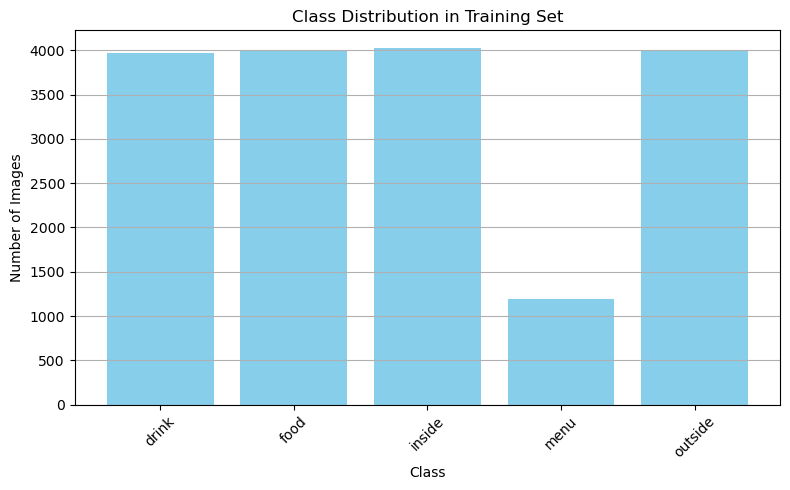

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Get class labels and counts
labels = train_gen.classes
class_names = list(train_gen.class_indices.keys())

# Count occurrences of each class
unique_classes, counts = np.unique(labels, return_counts=True)

# Print class distribution
for cls, count in zip(unique_classes, counts):
    print(f"Class '{class_names[cls]}': {count} images")

# Optional: Visualize with bar chart
plt.figure(figsize=(8, 5))
plt.bar(class_names, counts, color='skyblue')
plt.title("Class Distribution in Training Set")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


menu has fewer samples compared to the others.

The rest (drink, food, inside, outside) are fairly balanced.

So class imbalance is present, and need to address during training to avoid the model ignoring the minority class (menu).

In [32]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights based on frequency
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: 0.8658776126920171, 1: 0.8583125312031952, 2: 0.8546855580412628, 3: 2.886985726280437, 4: 0.8593851537115721}


In [33]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    class_weight=class_weights
)


Epoch 1/25


InvalidArgumentError: Graph execution error:

Detected at node PyFunc defined at (most recent call last):
<stack traces unavailable>
TypeError: `generator` yielded an element that did not match the expected structure. The expected structure was (tf.float32, tf.float32, tf.float32), but the yielded element was (array([[[[0.52156866, 0.427451  , 0.33333334],
         [0.44705886, 0.3529412 , 0.25882354],
         [0.38431376, 0.29803923, 0.20392159],
         ...,
         [0.48235297, 0.48235297, 0.47450984],
         [0.4784314 , 0.47450984, 0.45882356],
         [0.47058827, 0.4666667 , 0.45098042]],

        [[0.5529412 , 0.45882356, 0.3647059 ],
         [0.49411768, 0.40000004, 0.30588236],
         [0.44705886, 0.36078432, 0.26666668],
         ...,
         [0.4784314 , 0.4784314 , 0.47058827],
         [0.47058827, 0.47058827, 0.46274513],
         [0.4666667 , 0.46274513, 0.44705886]],

        [[0.5294118 , 0.4431373 , 0.34901962],
         [0.5019608 , 0.4156863 , 0.32156864]

Detect Overfitting / Underfitting (After Training) 
After training with class weights and tuned batch size, run the following code to visualize accuracy and loss trends

In [ ]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


Tuning 2 — Add Batch Normalization
We now modify your DNN to include BatchNormalization after each Dense and before Dropout.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.optimizers import Adam

tf.keras.backend.clear_session()

model = models.Sequential([
    Input(shape=(128, 128, 3)),
    layers.Flatten(),

    layers.Dense(1024),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(512),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.4),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.2),

    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.1),

    layers.Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['accuracy'])


Tuning 3 - Cross validation

In [ ]:
import numpy as np
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import StratifiedKFold

# Set parameters
image_size = (128, 128)
data_dir = 'C:/Users/Admin/Downloads/CV_PROJECT_1/keras_data/train'
class_names = os.listdir(data_dir)

X = []
y = []

for label, class_name in enumerate(class_names):
    class_dir = os.path.join(data_dir, class_name)
    for fname in os.listdir(class_dir):
        img_path = os.path.join(class_dir, fname)
        try:
            img = load_img(img_path, target_size=image_size)
            img_array = img_to_array(img) / 255.0  # normalize
            X.append(img_array)
            y.append(label)
        except:
            pass  # skip unreadable images

X = np.array(X)
y = np.array(y)

print("Loaded", len(X), "images.")


In [ ]:
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.utils import to_categorical

k = 5  # 5-fold CV
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

fold = 1
for train_idx, val_idx in skf.split(X, y):
    print(f"\n📂 Fold {fold}")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # One-hot encode labels
    y_train_cat = to_categorical(y_train, num_classes=len(class_names))
    y_val_cat = to_categorical(y_val, num_classes=len(class_names))

    # Build a fresh model for each fold
    tf.keras.backend.clear_session()
    model = models.Sequential([
        Input(shape=(128, 128, 3)),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(len(class_names), activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Train the model
    history = model.fit(X_train, y_train_cat, epochs=10, batch_size=16, validation_data=(X_val, y_val_cat))

    # Evaluate
    val_loss, val_acc = model.evaluate(X_val, y_val_cat, verbose=0)
    print(f"Fold {fold} Validation Accuracy: {val_acc:.4f}")

    fold += 1
